# 00 — UC2 Data Analysis & Partition Generation

**Use Case 2**: Wi-Fi AP Load Prediction (FLAG dataset)

This notebook:
1. Loads and explores the raw FLAG dataset
2. Visualizes AP load distributions
3. Generates Dirichlet-partitioned datasets for α ∈ {0.5, 1.0, 5.0, 10.0}

In [1]:
import sys, os
sys.path.append("..")
import UC2Utils as uc2
sys.path.insert(0, uc2.LIB_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from collections import Counter


sys.path.insert(0, uc2.LIB_DIR)

## 1. Load Raw Dataset

**IMPORTANT**: Place the pickle file `pickle_2019-05-13-on7_2min.pkl` in `data/raw/`.
Get this file from Francesc.

In [2]:
raw_path = uc2.get_raw_dataset_path()
print(f"Loading dataset from: {raw_path}")

sys.path.insert(0, os.path.abspath(".."))
from data.FlagsRegression.dataset import load_dataset
raw_data = load_dataset(path=raw_path, cache=False)

print(f"\nDataset shape: {raw_data.shape}")
print(f"Columns: {list(raw_data.columns)}")
print(f"Date range: {raw_data['datetime'].min()} → {raw_data['datetime'].max()}")
print(f"Number of unique APs: {raw_data['AP ID'].nunique()}")
print(f"\nFirst rows:")
raw_data.head()

Loading dataset from: /mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/data/raw/pickle_2019-05-13-on7_10min.pkl


100%|██████████| 2557/2557 [18:22<00:00,  2.32it/s]



Dataset shape: (2641932, 12)
Columns: ['datetime', 'Index', 'Bytes', 'Active Connections', 'Active Users', 'AP ID', 'day_of_week', 'day_of_week_sin', 'day_of_week_cos', 'hour_of_day', 'hour_of_day_sin', 'hour_of_day_cos']
Date range: 2019-04-22 15:00:00 → 2019-05-15 03:10:00
Number of unique APs: 2546

First rows:


,datetime,Index,Bytes,Active Connections,Active Users,AP ID,day_of_week,day_of_week_sin,day_of_week_cos,hour_of_day,hour_of_day_sin,hour_of_day_cos
2,2019-04-30 00:10:00,2,-13.0,2.558333,0.0,7-2324,1,0.866025,0.5,0,0.000000,1.000000
3,2019-04-30 00:20:00,3,-13.0,1.316667,0.0,7-2324,1,0.866025,0.5,0,0.000000,1.000000
5,2019-04-30 00:40:00,5,-13.0,0.696667,0.0,7-2324,1,0.866025,0.5,0,0.000000,1.000000
6,2019-04-30 00:50:00,6,-13.0,0.000000,0.0,7-2324,1,0.866025,0.5,0,0.000000,1.000000
8,2019-04-30 01:10:00,8,-13.0,0.008333,0.0,7-2324,1,0.866025,0.5,1,0.269797,0.962917


In [3]:
# Basic statistics
print("=== Target variable: Bytes ===")
print(raw_data["Bytes"].describe())
print(f"\nZero-load samples: {(raw_data['Bytes'] == 0).sum()} "
      f"({(raw_data['Bytes'] == 0).mean()*100:.1f}%)")
print(f"\n=== Active Users ===")
print(raw_data["Active Users"].describe())

=== Target variable: Bytes ===
count    2.641932e+06
mean    -4.051081e+00
std      6.767115e+00
min     -1.300000e+01
25%     -1.300000e+01
50%      5.479852e-02
75%      1.496060e+00
max      3.814321e+00
Name: Bytes, dtype: float64

Zero-load samples: 3 (0.0%)

=== Active Users ===
count    2.641932e+06
mean     2.087835e+00
std      4.106880e+00
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      1.100000e+02
Name: Active Users, dtype: float64


## 2. Visualize AP Load Distributions
Reproducing Figure 2 from the paper — histograms + KDE for sample APs

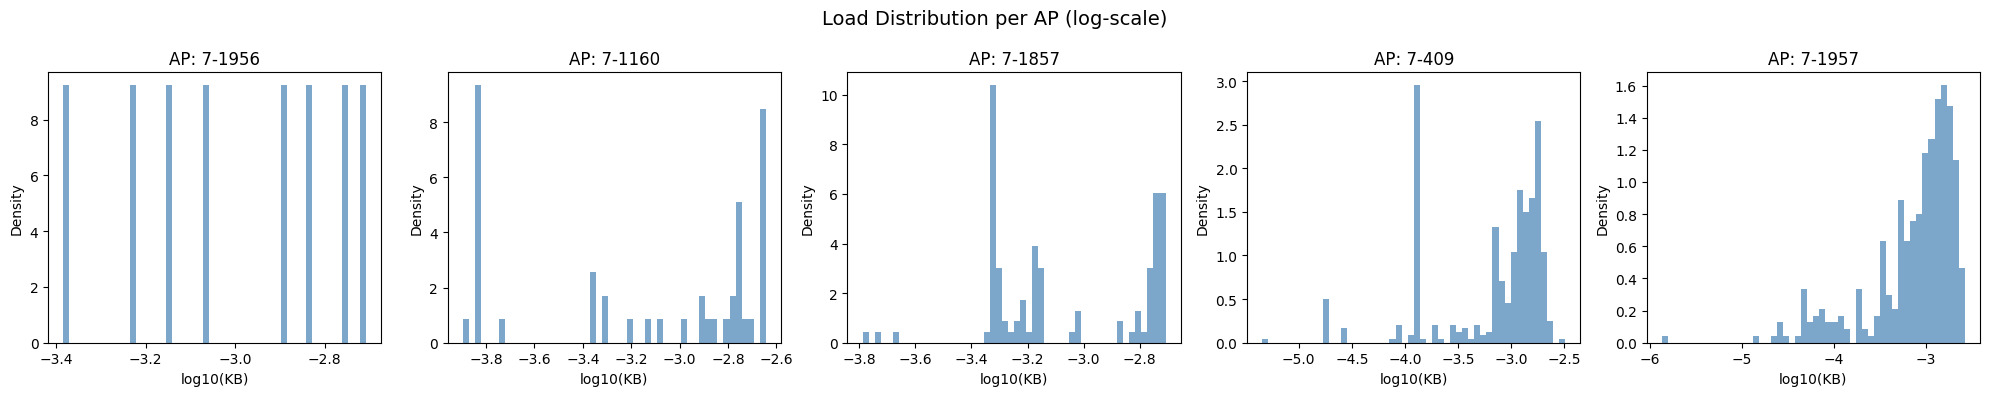

In [4]:
unique_aps = raw_data["AP ID"].unique()
sample_aps = np.random.choice(unique_aps, min(5, len(unique_aps)), replace=False)

fig, axes = plt.subplots(1, len(sample_aps), figsize=(4*len(sample_aps), 4))
if len(sample_aps) == 1:
    axes = [axes]

for ax, ap_id in zip(axes, sample_aps):
    ap_data = raw_data[raw_data["AP ID"] == ap_id]["Bytes"]
    # Log-transform for better visualization (as done in preprocessing)
    ap_log = np.log10(ap_data[ap_data > 0] * 1e-3)
    ax.hist(ap_log, bins=50, density=True, alpha=0.7, color="steelblue")
    ax.set_title(f"AP: {ap_id}")
    ax.set_xlabel("log10(KB)")
    ax.set_ylabel("Density")

plt.suptitle("Load Distribution per AP (log-scale)", fontsize=14)
plt.tight_layout()
plt.show()

Samples per AP — min: 2, max: 3234, median: 802


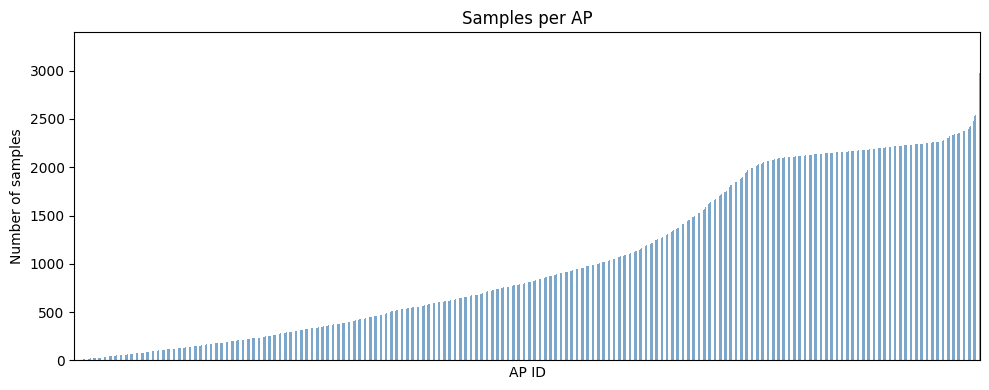

In [5]:
# Samples per AP
samples_per_ap = raw_data.groupby("AP ID").size()
print(f"Samples per AP — min: {samples_per_ap.min()}, max: {samples_per_ap.max()}, "
      f"median: {samples_per_ap.median():.0f}")

fig, ax = plt.subplots(figsize=(10, 4))
samples_per_ap.sort_values().plot(kind="bar", ax=ax, color="steelblue", alpha=0.7)
ax.set_xlabel("AP ID")
ax.set_ylabel("Number of samples")
ax.set_title("Samples per AP")
ax.set_xticks([])  # too many APs to label
plt.tight_layout()
plt.show()

## 3. Feature Engineering
The preprocessing pipeline (from `dataset.py`) does:
- Zero balancing: downsample zero-load rows to match non-zero count per AP
- Log transform: `Bytes → log10(Bytes * 1e-3)`
- Cyclical encoding: day_of_week and hour_of_day → sin/cos
- MinMax scaling to [1, 2]
- Time series windowing: lookback=60, steps={1,5,15,30}

**Features (6)**: Bytes, day_of_week_sin, day_of_week_cos, 
hour_of_day_sin, hour_of_day_cos, Active Users

In [6]:
features = ["Bytes", "day_of_week_sin", "day_of_week_cos",
            "hour_of_day_sin", "hour_of_day_cos", "Active Users"]
print("Feature columns used for training:")
for f in features:
    print(f"  {f}: range [{raw_data[f].min():.4f}, {raw_data[f].max():.4f}]")

Feature columns used for training:
  Bytes: range [-13.0000, 3.8143]
  day_of_week_sin: range [-0.8660, 0.8660]
  day_of_week_cos: range [-1.0000, 1.0000]
  hour_of_day_sin: range [-0.9977, 0.9977]
  hour_of_day_cos: range [-0.9907, 1.0000]
  Active Users: range [0.0000, 110.0000]


## 4. Generate Dirichlet Partitions

For each α ∈ {0.5, 1.0, 5.0, 10.0}, generate partitioned data
across 20 users (deployments). Lower α = more heterogeneity.

In [7]:
ALPHAS = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
LOOKBACK = 60
STEPS = 1
regenerate= False

for alpha in ALPHAS:
    if regenerate or not uc2.partitions_exist(alpha=alpha, lookback=LOOKBACK, steps=STEPS):
        uc2.generate_partitions(alpha=alpha, lookback=LOOKBACK, steps=STEPS,force=True)
    else:    
        print(f"Partitions for alpha={alpha} already exist. Skipping generation.")

Partitions for alpha=0.01 already exist. Skipping generation.
Partitions for alpha=0.1 already exist. Skipping generation.
Partitions for alpha=0.5 already exist. Skipping generation.
Partitions for alpha=1.0 already exist. Skipping generation.
Partitions for alpha=5.0 already exist. Skipping generation.
Partitions for alpha=10.0 already exist. Skipping generation.


## 5. Verify Partitions & Visualize Heterogeneity

In [8]:
import torch

for alpha in ALPHAS:
    part_path = os.path.join(
        uc2.DATA_PART, f"lookback_{LOOKBACK}", f"steps_{STEPS}",
        f"u20-alpha{alpha}-ratio1", "train", "train.pt"
    )
    with open(part_path, "rb") as f:
        data = torch.load(f, weights_only=False)

    samples = data["num_samples"]
    print(f"\nα={alpha}: {len(samples)} users, "
          f"total={sum(samples)} samples")
    print(f"  per-user: min={min(samples)}, max={max(samples)}, "
          f"std={np.std(samples):.1f}, CV={np.std(samples)/np.mean(samples):.2f}")


α=0.01: 20 users, total=88894 samples
  per-user: min=2123, max=5676, std=1019.1, CV=0.23

α=0.1: 20 users, total=88894 samples
  per-user: min=2858, max=5487, std=615.3, CV=0.14

α=0.5: 20 users, total=88894 samples
  per-user: min=3684, max=5181, std=328.0, CV=0.07

α=1.0: 20 users, total=88894 samples
  per-user: min=3594, max=4869, std=262.4, CV=0.06

α=5.0: 20 users, total=88894 samples
  per-user: min=4018, max=4690, std=160.5, CV=0.04

α=10.0: 20 users, total=88894 samples
  per-user: min=4036, max=4632, std=131.1, CV=0.03


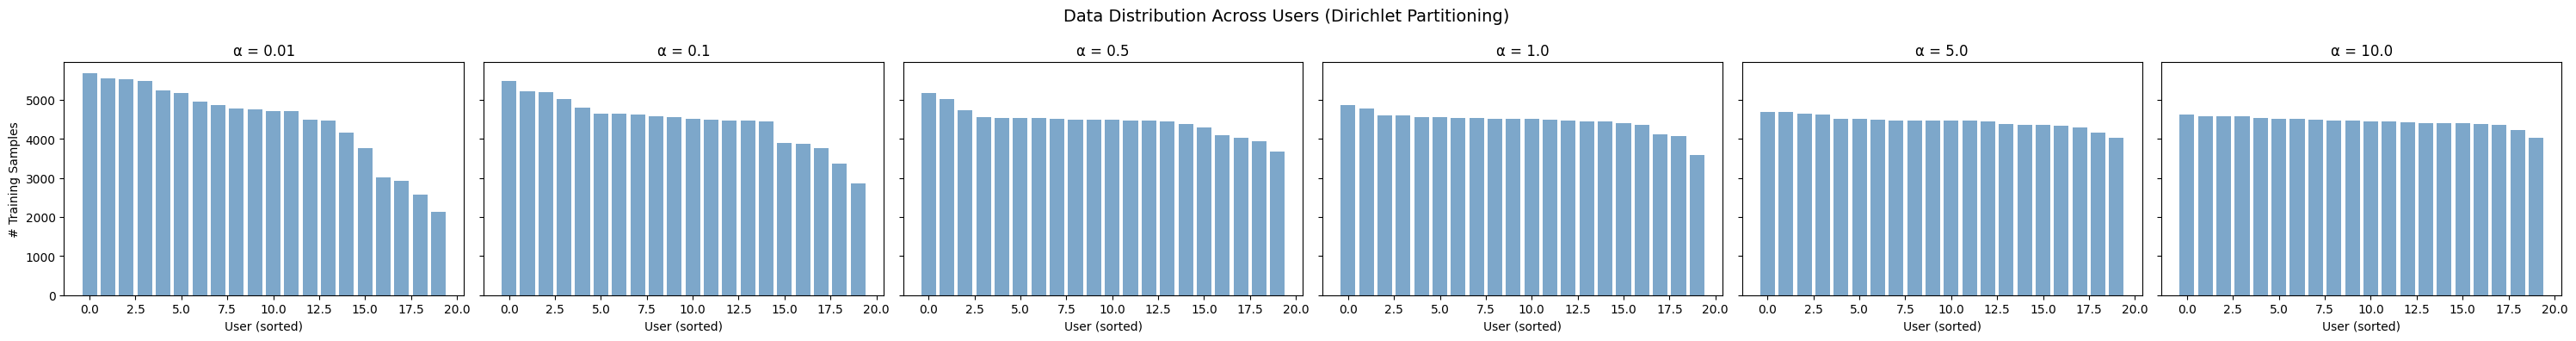

In [9]:
# Visualize sample distribution across users for each alpha
fig, axes = plt.subplots(1, len(ALPHAS), figsize=(5*len(ALPHAS), 4), sharey=True)

for ax, alpha in zip(axes, ALPHAS):
    part_path = os.path.join(
        uc2.DATA_PART, f"lookback_{LOOKBACK}", f"steps_{STEPS}",
        f"u20-alpha{alpha}-ratio1", "train", "train.pt"
    )
    with open(part_path, "rb") as f:
        data = torch.load(f, weights_only=False)

    samples = data["num_samples"]
    ax.bar(range(len(samples)), sorted(samples, reverse=True),
           color="steelblue", alpha=0.7)
    ax.set_title(f"α = {alpha}")
    ax.set_xlabel("User (sorted)")
    if ax == axes[0]:
        ax.set_ylabel("# Training Samples")

plt.suptitle("Data Distribution Across Users (Dirichlet Partitioning)", fontsize=14)
plt.tight_layout()
plt.show()

## Summary

- Raw dataset loaded and explored: ~7400 APs, 49 days, 2-min windows
- Partitions generated for α ∈ {0.5, 1.0, 5.0, 10.0} with 20 users each
- Lower α → more heterogeneous distribution → harder FL problem
- Data saved in `data/partitions/lookback_60/steps_1/u20-alpha{α}-ratio1/`

In [10]:
# Check TEST partitions for zero-sample users
for alpha in ALPHAS:
    test_path = os.path.join(
        uc2.DATA_PART, f"lookback_{LOOKBACK}", f"steps_{STEPS}",
        f"u20-alpha{alpha}-ratio1", "test", "test.pt"
    )
    with open(test_path, "rb") as f:
        data = torch.load(f, weights_only=False)

    samples = data["num_samples"]
    zeros = sum(1 for s in samples if s == 0)
    print(f"α={alpha}: test samples per user = {samples}")
    if zeros:
        print(f"  ⚠️  {zeros} users have ZERO test samples!")

α=0.01: test samples per user = [3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000]
α=0.1: test samples per user = [3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000]
α=0.5: test samples per user = [3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000]
α=1.0: test samples per user = [3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000]
α=5.0: test samples per user = [3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000]
α=10.0: test samples per user = [3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000]


In [11]:
import torch

print(f"{'α':<8} {'Mode':<6} {'Users':>5} {'Total':>8} {'Min':>7} {'Max':>7} {'Zeros':>5}")
print("─" * 55)

for alpha in ALPHAS:
    part_dir = os.path.join(
        uc2.DATA_PART, f"lookback_{LOOKBACK}", f"steps_{STEPS}",
        f"u20-alpha{alpha}-ratio1"
    )
    for mode in ["train", "test"]:
        path = os.path.join(part_dir, mode, f"{mode}.pt")
        data = torch.load(path, weights_only=False)
        s = data["num_samples"]
        zeros = sum(1 for x in s if x == 0)
        flag = " ⚠️" if zeros else ""
        print(f"{alpha:<8} {mode:<6} {len(s):>5} {sum(s):>8} {min(s):>7} {max(s):>7} {zeros:>5}{flag}")

    # With unknown_test=True, all users should have identical test samples
    test_data = torch.load(os.path.join(part_dir, "test", "test.pt"), weights_only=False)
    ts = test_data["num_samples"]
    if len(set(ts)) == 1:
        print(f"         ✓ All users have equal test samples ({ts[0]})")
    else:
        print(f"         ⚠️ Test samples vary: {ts}")
    print()

α        Mode   Users    Total     Min     Max Zeros
───────────────────────────────────────────────────────
0.01     train     20    88894    2123    5676     0
0.01     test      20    60000    3000    3000     0
         ✓ All users have equal test samples (3000)

0.1      train     20    88894    2858    5487     0
0.1      test      20    60000    3000    3000     0
         ✓ All users have equal test samples (3000)

0.5      train     20    88894    3684    5181     0
0.5      test      20    60000    3000    3000     0
         ✓ All users have equal test samples (3000)

1.0      train     20    88894    3594    4869     0
1.0      test      20    60000    3000    3000     0
         ✓ All users have equal test samples (3000)

5.0      train     20    88894    4018    4690     0
5.0      test      20    60000    3000    3000     0
         ✓ All users have equal test samples (3000)

10.0     train     20    88894    4036    4632     0
10.0     test      20    60000    3000    3

In [12]:
import os, json
import numpy as np
import torch
import matplotlib.pyplot as plt
import UC2Utils as uc2
import sys; sys.path.insert(0, uc2.LIB_DIR)
import importlib
import new_partitions

importlib.reload(new_partitions)

from new_partitions import generate_labelskew_partitions

ALPHAS  = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]   # full sweep
LOOKBACK, STEPS, N_USERS, N_BINS = 60, 1, 20, 10

# ── PARTITION #2: client-local test (Option A) ──
# Each client is tested on its OWN load regime -> heterogeneity shows in per-client spread.
# floor_frac MUST match the global run in the next cell so the TRAIN sets are identical
# (only the TEST design should differ between the two partitions).
# force=True is required on the first corrected run to overwrite any stale global test.pt
# that an earlier session may have written into new_partitions/.
for a in ALPHAS:
    generate_labelskew_partitions(uc2, a, lookback=LOOKBACK, steps=STEPS,
                                  n_users=N_USERS, n_bins=N_BINS,
                                  test_mode="client_local",
                                  floor_frac=0.2,
                                  force=True)

NEW_ROOT = os.path.join(uc2.DATA_PART, "new_partitions",
                        f"lookback_{LOOKBACK}", f"steps_{STEPS}")
print("client-local (Option A) root:", NEW_ROOT)


[..] Generating LABEL-SKEW partition: alpha=0.01, bins=10, users=20, test_mode=client_local
 * Total data set samples: 2641932
      - APs for training/validation: ['7-1651', '7-933', '7-324', '7-3838', '7-2551', '7-2294', '7-199', '7-662', '7-4132', '7-864', '7-1642', '7-1899', '7-3973', '7-701', '7-2559', '7-2540', '7-40', '7-2507', '7-178', '7-2864', '7-2937', '7-640', '7-460', '7-496', '7-1022', '7-1002', '7-575', '7-1209', '7-3057', '7-4191', '7-3928', '7-238', '7-527', '7-621', '7-156', '7-1230', '7-678', '7-2016', '7-3085', '7-4170', '7-3428', '7-1736', '7-1900', '7-1071', '7-842', '7-2905', '7-2068', '7-317', '7-437', '7-1809', '7-936', '7-391', '7-584', '7-3868', '7-2780', '7-3028', '7-2778', '7-895', '7-1106', '7-2697', '7-381', '7-1841', '7-274', '7-106', '7-1462', '7-1727', '7-4096', '7-511', '7-3610', '7-372', '7-1268', '7-2912', '7-104', '7-2157', '7-924', '7-1886', '7-670', '7-2037', '7-1442', '7-610', '7-313', '7-2677', '7-1040', '7-1278', '7-1455', '7-186', '7-745', '7

In [13]:
# ── Cell A: generate the THIRD partition (shared global test pool, Option B) ──
import os, importlib
import new_partitions
importlib.reload(new_partitions)
from new_partitions import generate_labelskew_partitions

ALPHAS  = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
LOOKBACK, STEPS, N_USERS, N_BINS = 60, 1, 20, 10

for a in ALPHAS:
    generate_labelskew_partitions(
        uc2, a, lookback=LOOKBACK, steps=STEPS,
        n_users=N_USERS, n_bins=N_BINS,
        test_mode="global",          # shared global test pool
        floor_frac=0.2,              # match whatever you used for client_local
        force=True)                  # overwrite any stale file

GLOBAL_ROOT = os.path.join(uc2.DATA_PART, "new_partitions_global",
                           f"lookback_{LOOKBACK}", f"steps_{STEPS}")
LOCAL_ROOT  = os.path.join(uc2.DATA_PART, "new_partitions",
                           f"lookback_{LOOKBACK}", f"steps_{STEPS}")
print("global  root:", GLOBAL_ROOT)
print("local   root:", LOCAL_ROOT)

[..] Generating LABEL-SKEW partition: alpha=0.01, bins=10, users=20, test_mode=global
 * Total data set samples: 2641932
      - APs for training/validation: ['7-1651', '7-933', '7-324', '7-3838', '7-2551', '7-2294', '7-199', '7-662', '7-4132', '7-864', '7-1642', '7-1899', '7-3973', '7-701', '7-2559', '7-2540', '7-40', '7-2507', '7-178', '7-2864', '7-2937', '7-640', '7-460', '7-496', '7-1022', '7-1002', '7-575', '7-1209', '7-3057', '7-4191', '7-3928', '7-238', '7-527', '7-621', '7-156', '7-1230', '7-678', '7-2016', '7-3085', '7-4170', '7-3428', '7-1736', '7-1900', '7-1071', '7-842', '7-2905', '7-2068', '7-317', '7-437', '7-1809', '7-936', '7-391', '7-584', '7-3868', '7-2780', '7-3028', '7-2778', '7-895', '7-1106', '7-2697', '7-381', '7-1841', '7-274', '7-106', '7-1462', '7-1727', '7-4096', '7-511', '7-3610', '7-372', '7-1268', '7-2912', '7-104', '7-2157', '7-924', '7-1886', '7-670', '7-2037', '7-1442', '7-610', '7-313', '7-2677', '7-1040', '7-1278', '7-1455', '7-186', '7-745', '7-88', 

In [14]:
def gini(values):
    v = np.sort(np.array(values, dtype=float)); n = len(v); c = np.cumsum(v)
    return (n + 1 - 2 * np.sum(c) / c[-1]) / n if c[-1] > 0 else 0.0
 
def load_train(root, a):
    p = os.path.join(root, f"u{N_USERS}-alpha{a}-ratio1", "train", "train.pt")
    return torch.load(p, weights_only=False)
 
print(f"{'α':<6} {'y-mean Gini':>12} {'y-mean σ':>10} {'samp Gini':>10} "
      f"{'min':>7} {'max':>7}")
new_stats = {}
for a in ALPHAS:
    d = load_train(NEW_ROOT, a)
    ymeans = [d['user_data'][u]['y'].numpy().mean() for u in d['users']]
    spu = d['num_samples']
    new_stats[a] = dict(ymean_gini=gini(ymeans), ymean_sigma=float(np.std(ymeans)),
                        samp_gini=gini(spu), mn=min(spu), mx=max(spu))
    print(f"{a:<6} {gini(ymeans):>12.4f} {np.std(ymeans):>10.4f} "
          f"{gini(spu):>10.4f} {min(spu):>7} {max(spu):>7}")
 
# Compare against the OLD AP-ID partitions if present (drop-in: same names).
OLD_ROOT = os.path.join(uc2.DATA_PART, f"lookback_{LOOKBACK}", f"steps_{STEPS}")
print("\nOLD (AP-ID) vs NEW (y-bin) per-user y-mean Gini:")
print(f"{'α':<6} {'OLD':>10} {'NEW':>10}  {'×more skew':>10}")
for a in ALPHAS:
    try:
        do = load_train(OLD_ROOT, a)
        ymo = [do['user_data'][u]['y'].numpy().mean() for u in do['users']]
        go = gini(ymo)
    except Exception:
        go = float('nan')
    gn = new_stats[a]['ymean_gini']
    ratio = gn / go if go and not np.isnan(go) and go > 0 else float('nan')
    print(f"{a:<6} {go:>10.4f} {gn:>10.4f}  {ratio:>10.1f}")

α       y-mean Gini   y-mean σ  samp Gini     min     max
0.01         0.0686     0.2078     0.5550     883   26787
0.1          0.0692     0.2202     0.3602    1046   15574
0.5          0.0627     0.1767     0.1709    2306    7265
1.0          0.0764     0.2127     0.1152    2395    6239
5.0          0.0398     0.1065     0.0691    3233    5251
10.0         0.0309     0.0827     0.0575    3270    5275

OLD (AP-ID) vs NEW (y-bin) per-user y-mean Gini:
α             OLD        NEW  ×more skew
0.01       0.0299     0.0686         2.3
0.1        0.0166     0.0692         4.2
0.5        0.0107     0.0627         5.9
1.0        0.0076     0.0764        10.0
5.0        0.0045     0.0398         8.8
10.0       0.0030     0.0309        10.4


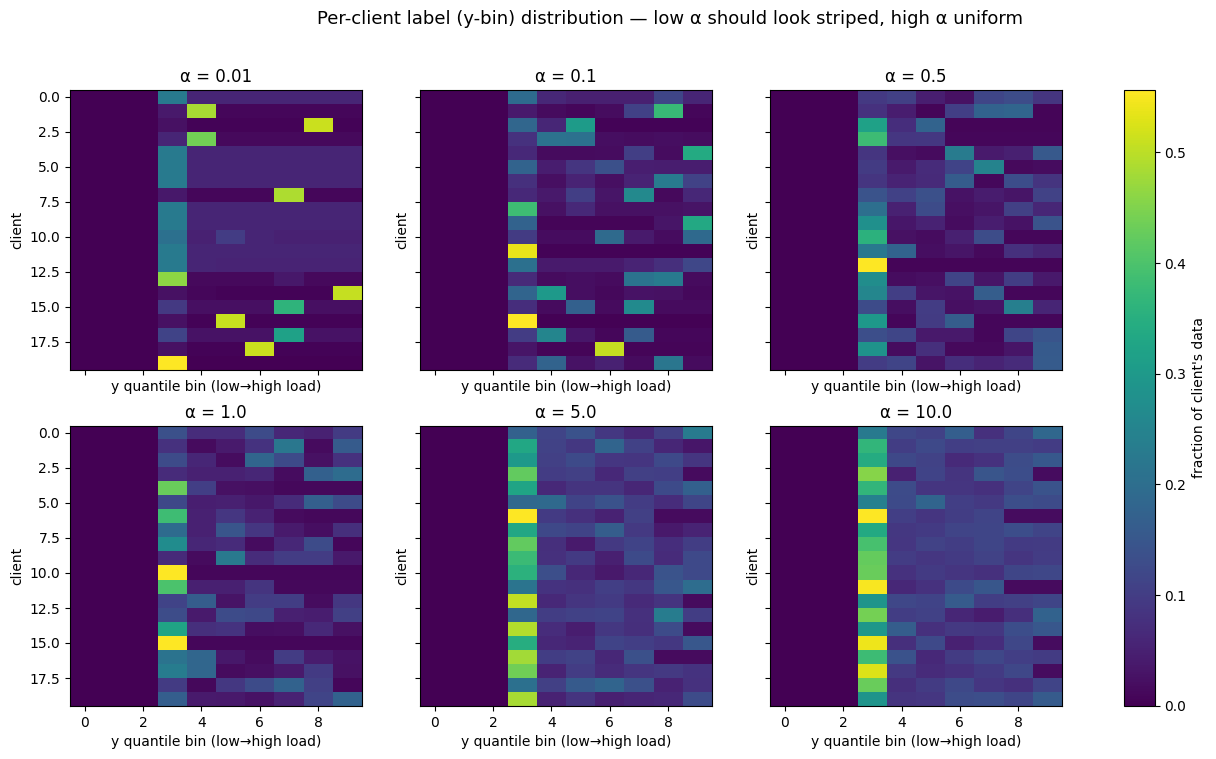

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
for ax, a in zip(axes.ravel(), ALPHAS):
    meta = json.load(open(os.path.join(
        NEW_ROOT, f"u{N_USERS}-alpha{a}-ratio1", "partition_meta.json")))
    H = np.array(meta['bin_histogram_per_user'], dtype=float)   # users × bins
    Hn = H / H.sum(axis=1, keepdims=True)                       # row-normalise
    im = ax.imshow(Hn, aspect='auto', cmap='viridis')
    ax.set_title(f"α = {a}")
    ax.set_xlabel("y quantile bin (low→high load)")
    ax.set_ylabel("client")
fig.suptitle("Per-client label (y-bin) distribution — low α should look striped, "
             "high α uniform", fontsize=13)
fig.colorbar(im, ax=axes.ravel().tolist(), label="fraction of client's data")
plt.show()
# Interpretation: at low α each ROW concentrates on a few columns (clients
# specialise in a load regime). At high α rows are flat (IID). If low-α rows are
# already flat, the skew didn't take — raise N_BINS or lower floor_frac.

## 6. Verify the TEST designs (Option A vs global)
Cell 20 compares **train** skew. Cell 21 shows the **train** y-bin heatmap.
The cell below reads the actual `test.pt` files and verifies that the
client-local test set tracks each client's training regime, while the
global pool is identical for every client.


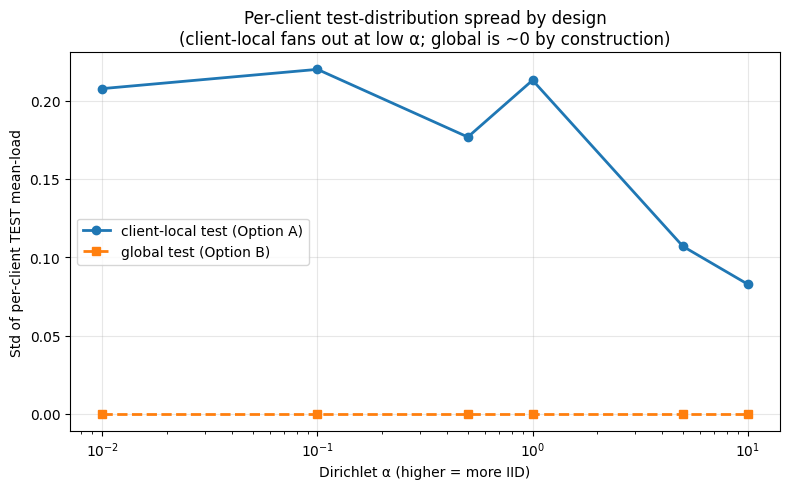

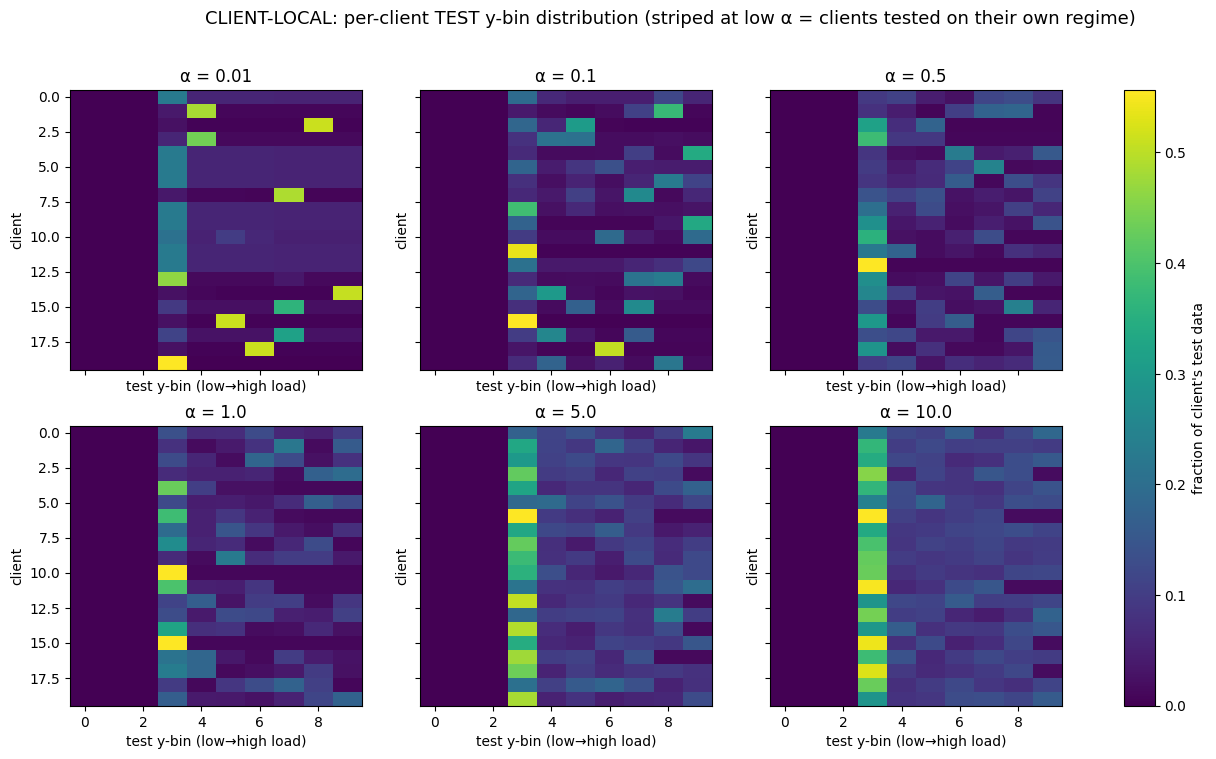

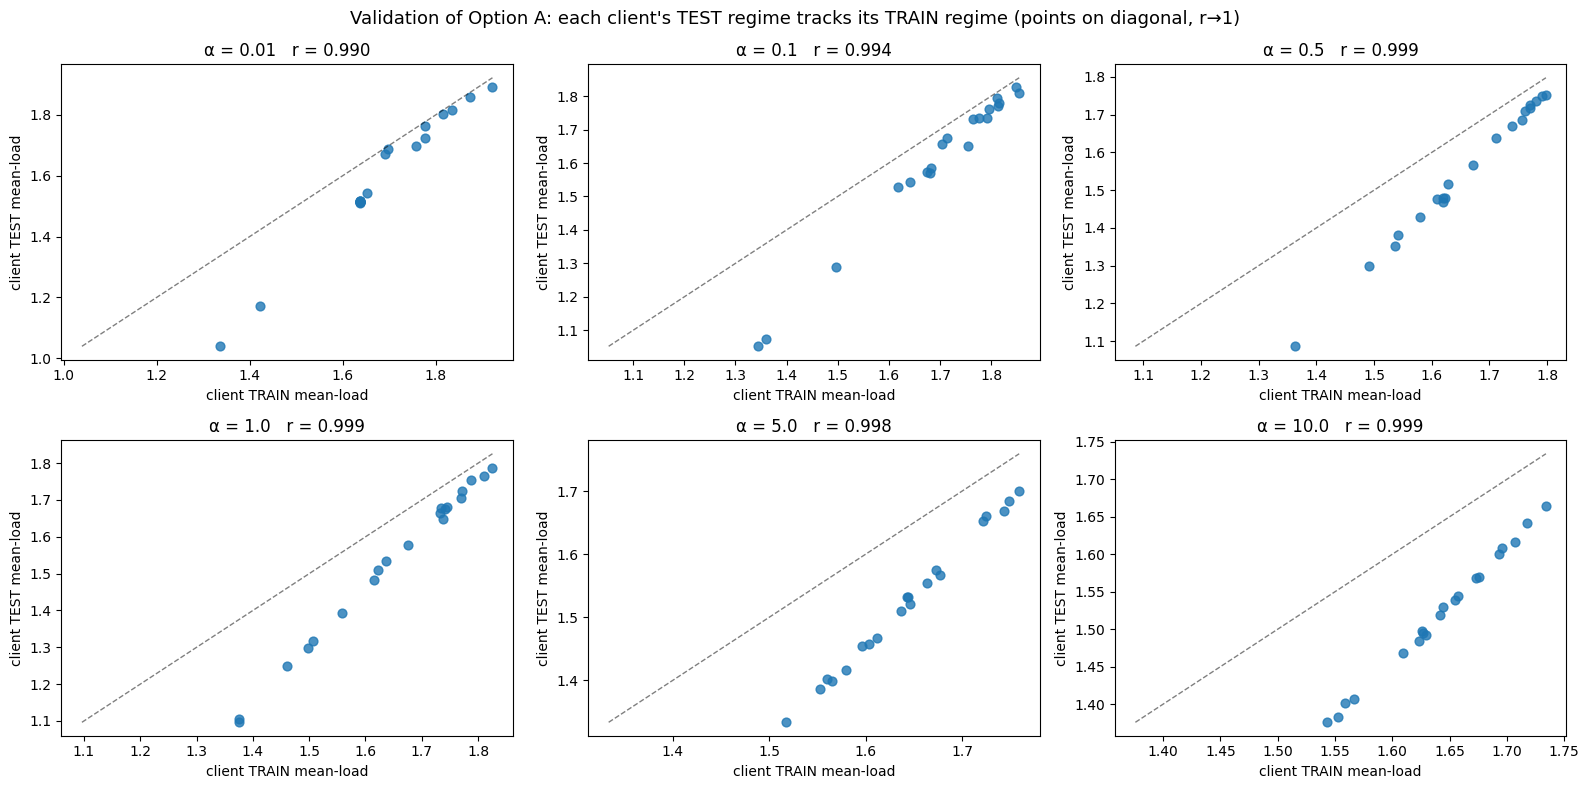

α      loc test μ-std glo test μ-std    loc test n: min/max  train/test r
0.01           0.2077         0.0000               176/3000         0.990
0.1            0.2200         0.0000               209/3000         0.994
0.5            0.1768         0.0000               461/1453         0.999
1.0            0.2131         0.0000               479/1247         0.999
5.0            0.1070         0.0000               646/1050         0.998
10.0           0.0828         0.0000               654/1055         0.999


In [16]:
# ── Cell B: VERIFY the test designs (reads actual test.pt, bins TEST y) ──
# This is the cell that answers 'did Option A actually work?':
#   fig1: client-local spread fans out at low alpha; global stays ~0
#   fig2: client-local per-client TEST y-bin heatmap (striped at low alpha)
#   fig3: each client's TEST regime vs its TRAIN regime (points on diagonal, r->1)
# NOTE cell 21 above shows TRAIN skew (meta histogram); THIS shows the TEST set.

# ── Cell B: compare CLIENT-LOCAL vs GLOBAL test designs ──
import os, json
import numpy as np
import torch
import matplotlib.pyplot as plt

ALPHAS  = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
LOOKBACK, STEPS, N_USERS, N_BINS = 60, 1, 20, 10
LOCAL_ROOT  = os.path.join(uc2.DATA_PART, "new_partitions",
                           f"lookback_{LOOKBACK}", f"steps_{STEPS}")
GLOBAL_ROOT = os.path.join(uc2.DATA_PART, "new_partitions_global",
                           f"lookback_{LOOKBACK}", f"steps_{STEPS}")

def _part_dir(root, a):
    return os.path.join(root, f"u{N_USERS}-alpha{a}-ratio1")

def load_meta(root, a):
    with open(os.path.join(_part_dir(root, a), "partition_meta.json")) as f:
        return json.load(f)

def load_pt(root, a, mode):
    return torch.load(os.path.join(_part_dir(root, a), mode, f"{mode}.pt"),
                      weights_only=False)

def per_client_y(root, a, mode):
    """Return list[n_users] of flat test-y arrays."""
    d = load_pt(root, a, mode)
    out = []
    for u in d["users"]:
        y = d["user_data"][u]["y"].numpy()
        out.append(y.reshape(len(y), -1)[:, 0])
    return out, d["num_samples"]

def bin_counts_per_client(ys, edges, n_bins):
    """Histogram each client's y onto the TRAIN edges -> (n_users, n_bins)."""
    edges = np.asarray(edges)
    H = np.zeros((len(ys), n_bins))
    for i, y in enumerate(ys):
        b = np.clip(np.digitize(y, edges) - 1, 0, n_bins - 1)
        for k in range(n_bins):
            H[i, k] = np.sum(b == k)
    return H

# ============================================================
# FIGURE 1 — per-client TEST mean-load spread vs alpha
#   client-local should fan out as alpha drops; global stays flat at ~0
# ============================================================
loc_std, glo_std = [], []
for a in ALPHAS:
    ys_loc, _ = per_client_y(LOCAL_ROOT, a, "test")
    ys_glo, _ = per_client_y(GLOBAL_ROOT, a, "test")
    loc_std.append(np.std([y.mean() for y in ys_loc]))
    glo_std.append(np.std([y.mean() for y in ys_glo]))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ALPHAS, loc_std, "o-", lw=2, label="client-local test (Option A)")
ax.plot(ALPHAS, glo_std, "s--", lw=2, label="global test (Option B)")
ax.set_xscale("log")
ax.set_xlabel("Dirichlet α (higher = more IID)")
ax.set_ylabel("Std of per-client TEST mean-load")
ax.set_title("Per-client test-distribution spread by design\n"
             "(client-local fans out at low α; global is ~0 by construction)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ============================================================
# FIGURE 2 — per-client TEST bin heatmaps (client-local), one panel per alpha
#   low α: striped rows (clients specialise). high α: flat rows (IID)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
for ax, a in zip(axes.ravel(), ALPHAS):
    edges = load_meta(LOCAL_ROOT, a)["bin_edges"]
    ys, _ = per_client_y(LOCAL_ROOT, a, "test")
    H = bin_counts_per_client(ys, edges, N_BINS)
    Hn = H / np.clip(H.sum(1, keepdims=True), 1, None)
    im = ax.imshow(Hn, aspect="auto", cmap="viridis", vmin=0, vmax=Hn.max())
    ax.set_title(f"α = {a}")
    ax.set_xlabel("test y-bin (low→high load)")
    ax.set_ylabel("client")
fig.suptitle("CLIENT-LOCAL: per-client TEST y-bin distribution "
             "(striped at low α = clients tested on their own regime)", fontsize=13)
fig.colorbar(im, ax=axes.ravel().tolist(), label="fraction of client's test data")
plt.show()

# ============================================================
# FIGURE 3 — TRAIN vs TEST regime correlation (validates Option A)
#   for each client: train mean-load (from meta hist) vs test mean-load
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, a in zip(axes.ravel(), ALPHAS):
    meta = load_meta(LOCAL_ROOT, a)
    edges = np.asarray(meta["bin_edges"])
    centers = (edges[:-1] + edges[1:]) / 2
    Htr = np.asarray(meta["bin_histogram_per_user"], dtype=float)  # train hist
    train_meanload = (Htr * centers).sum(1) / np.clip(Htr.sum(1), 1, None)
    ys, _ = per_client_y(LOCAL_ROOT, a, "test")
    test_meanload = np.array([y.mean() for y in ys])
    r = np.corrcoef(train_meanload, test_meanload)[0, 1]
    ax.scatter(train_meanload, test_meanload, s=40, alpha=0.8)
    lo = min(train_meanload.min(), test_meanload.min())
    hi = max(train_meanload.max(), test_meanload.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.5)
    ax.set_title(f"α = {a}   r = {r:.3f}")
    ax.set_xlabel("client TRAIN mean-load")
    ax.set_ylabel("client TEST mean-load")
fig.suptitle("Validation of Option A: each client's TEST regime tracks its TRAIN regime "
             "(points on diagonal, r→1)", fontsize=13)
plt.tight_layout(); plt.show()

# ============================================================
# TABLE — numeric summary
# ============================================================
print(f"{'α':<6} {'loc test μ-std':>14} {'glo test μ-std':>14} "
      f"{'loc test n: min/max':>22} {'train/test r':>13}")
for a in ALPHAS:
    ys_loc, n_loc = per_client_y(LOCAL_ROOT, a, "test")
    ys_glo, _     = per_client_y(GLOBAL_ROOT, a, "test")
    meta = load_meta(LOCAL_ROOT, a)
    edges = np.asarray(meta["bin_edges"]); centers = (edges[:-1]+edges[1:])/2
    Htr = np.asarray(meta["bin_histogram_per_user"], dtype=float)
    tr_ml = (Htr*centers).sum(1)/np.clip(Htr.sum(1),1,None)
    te_ml = np.array([y.mean() for y in ys_loc])
    r = np.corrcoef(tr_ml, te_ml)[0,1]
    print(f"{a:<6} {np.std([y.mean() for y in ys_loc]):>14.4f} "
          f"{np.std([y.mean() for y in ys_glo]):>14.4f} "
          f"{str(min(n_loc))+'/'+str(max(n_loc)):>22} {r:>13.3f}")
